# **Housing Price Analysis**
### Data Science & Engineering — Project Exam

In [100]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# **Loading and Inspection of data**

In [103]:
df = pd.read_csv('Housing.csv')

In [105]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [107]:
print("Shape:", df.shape)

Shape: (545, 13)


In [109]:
print(df.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [111]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [113]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


# **Data Cleaning**

In [315]:
# Checking for missing data

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing

,Missing Count,Percentage
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [319]:
# Checking for duplicates 

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)


Duplicate rows: 0


In [321]:
# Price Outlier Detection

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

price_outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print("Price Outliers:", len(price_outliers))
price_outliers.head()

Price Outliers: 15


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [323]:
# Area Outlier Detection

Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

area_outliers = df[(df['area'] < lower) | (df['area'] > upper)]

print("Area Outliers:", len(area_outliers))
area_outliers.head()

Area Outliers: 12


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
56,7343000,11440,4,1,2,yes,no,yes,no,no,1,yes,semi-furnished
64,7000000,11175,3,1,1,yes,no,yes,no,yes,1,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished


In [325]:
# verifying categorical values

expected_values = {
    'mainroad':['yes','no'],
    'guestroom':['yes','no'],
    'basement':['yes','no'],
    'hotwaterheating':['yes','no'],
    'airconditioning':['yes','no'],
    'prefarea':['yes','no']
}

for col, values in expected_values.items():
    invalid = set(df[col].unique()) - set(values)
    print(col, invalid)

mainroad set()
guestroom set()
basement set()
hotwaterheating set()
airconditioning set()
prefarea set()


# **Data Quality Summary**

#### The Housing dataset contains 545 records and 13 variables. No missing values or duplicate records were found during the data quality assessment. The categorical variables contained only expected values and required no corrcetion. Outlier analysis identified some extreme values in house price and area, but these appear to represent genuinely expensive or large properties rather than dat-entry errors. Overall, the dataset is clean and suitable for exploratory data analysis.

# **Analysis Answers**

### Pricing and Size

In [330]:
# 1. What is the average, median, and maximum house price in the dataset?

average_price = df['price'].mean()
median_price = df['price'].median()
maximum_price = df['price'].max()

print("Average Price:", average_price)
print("Median Price:", median_price)
print("Maximum Price:", maximum_price)


Average Price: 4766729.247706422
Median Price: 4340000.0
Maximum Price: 13300000


In [332]:
print("The average price is higher than the median, suggesting the presence of some high-priced house that pull the average upward")

The average price is higher than the median, suggesting the presence of some high-priced house that pull the average upward


In [334]:
# 2. What is the correlation between area and price? Is it strong or weak?

correlation = df['area'].corr(df['price'])

print("Correlation between Area and Price:", correlation)

if correlation > 0.7:
    print("It is a strong positive correlation")
elif correlation > 0.3:
    print("It is a moderate positive correlation")
else:
    print("It is a strong weak correlation")

Correlation between Area and Price: 0.5359973457780797
It is a moderate positive correlation


In [336]:
# 3. What are the top 5 most expensive houses? What features do they share?

top5_expensive = df.sort_values(by='price', ascending=False).head(5)

top5_expensive

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [338]:

print("The most expensive houses tend to have: Large floor areas, multiple bathrooms, multiple stories, air conditioning, furnished or semi-furnished status")
    

The most expensive houses tend to have: Large floor areas, multiple bathrooms, multiple stories, air conditioning, furnished or semi-furnished status


### Feature Impact on Price

In [341]:
# 4. Do houses on the main road sell for more than those that are not? Compare the average prices.

mainroad_price = df.groupby('mainroad')['price'].mean()

print(mainroad_price)

mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64


In [343]:
print ("Yes, houses located on the main road sell for approximately 1.59 million more on average")

Yes, houses located on the main road sell for approximately 1.59 million more on average


In [345]:
# 5. Does having air conditioning significantly affect house price? Show the mean price for each group.

aircon_price = df.groupby('airconditioning')['price'].mean()

print(aircon_price)

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64


In [347]:
print ("Yes, houses with air conditioning are listed for higher prices, about 1.82 million more than the average")

Yes, houses with air conditioning are listed for higher prices, about 1.82 million more than the average


In [349]:
# 6. How does furnishing status affect price? Show the average price for each category and rank them.
furnishing_price = (
    df.groupby('furnishingstatus')['price']
    .mean()
    .sort_values(ascending=False)
)

print(furnishing_price)


furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64


In [351]:
print ("Fully furnished homes attract the highest prices, while unfurnished properties are the least expensive")

Fully furnished homes attract the highest prices, while unfurnished properties are the least expensive


In [353]:
# 7. Do houses in the preferred area (prefarea) command a price premium? By how much on average?

prefarea_price = df.groupby('prefarea')['price'].mean()

print(prefarea_price)

prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64


In [355]:
print (" Being located in a preferred area increases the average selling price by approximately 1.45 million")

 Being located in a preferred area increases the average selling price by approximately 1.45 million


### Distributions and Patterns 

In [358]:
# 8. What is the most common number of bedrooms? What percentage of houses have exactly 3 bedrooms?

mode_bedrooms = df['bedrooms'].mode()[0]

print("Most Common Bedrooms:", mode_bedrooms)

Most Common Bedrooms: 3


In [360]:
three_bedroom_percent = (
    len(df[df['bedrooms'] == 3])
    / len(df)
) * 100

print("Percentage:", round(three_bedroom_percent, 2))

Percentage: 55.05


In [362]:
# 9. How many houses have both a basement and air conditioning? What is the average price for this group?

basement_aircon = df[
    (df['basement'] == 'yes') &
    (df['airconditioning'] == 'yes')
]

print("Number of Houses:", len(basement_aircon))

avg_price = basement_aircon['price'].mean()

print("Average Price:", avg_price)

Number of Houses: 66
Average Price: 6081196.96969697


In [364]:
# Is there a relationship between the number of stories and price? Describe the trend.
stories_price = (
    df.groupby('stories')['price']
    .mean()
)

print(stories_price)

stories
1    4.170659e+06
2    4.764074e+06
3    5.685436e+06
4    7.208450e+06
Name: price, dtype: float64


In [366]:
print ("The house prices consistently increase as the number of stories increases. Four-story houses are the most expensive on average")

The house prices consistently increase as the number of stories increases. Four-story houses are the most expensive on average


# **Data Visualisations**
 


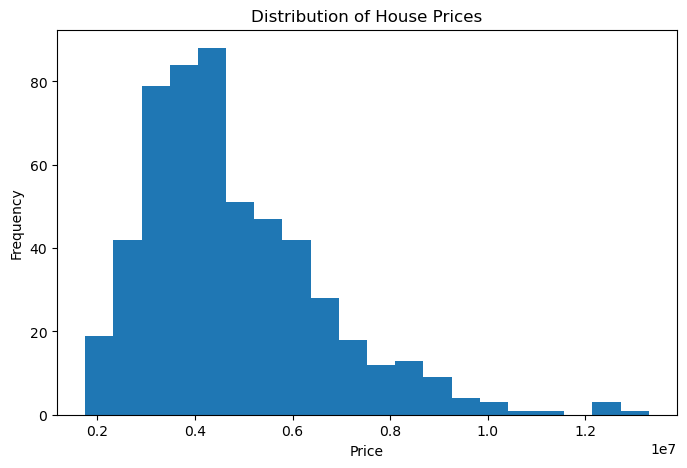

In [395]:
# 1. Histogram 

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Saving the pLot locally to be able to use in the report
plt.savefig("hist.png", bbox_inches="tight", pad_inches=0.1)

plt.show()

In [377]:
plt.savefig("hist.png")

<Figure size 640x480 with 0 Axes>

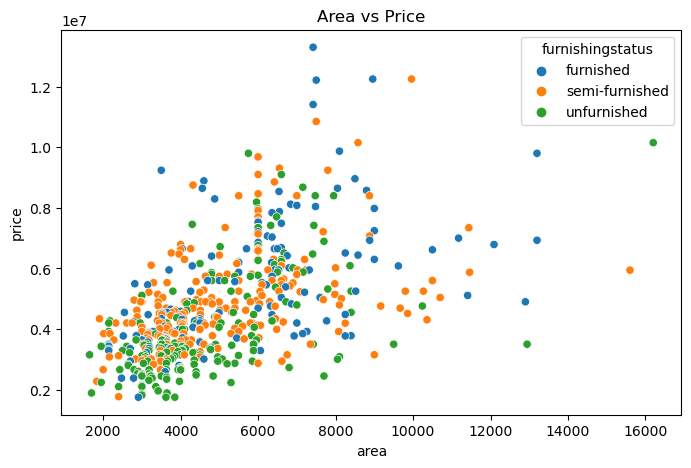

In [399]:
# 2. Scatter Plot 

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='area',
    y='price',
    hue='furnishingstatus'
)

plt.title('Area vs Price')

# Saving the pLot locally to be able to use in the report
plt.savefig("scatterplot.png", bbox_inches="tight", pad_inches=0.1)

plt.show()

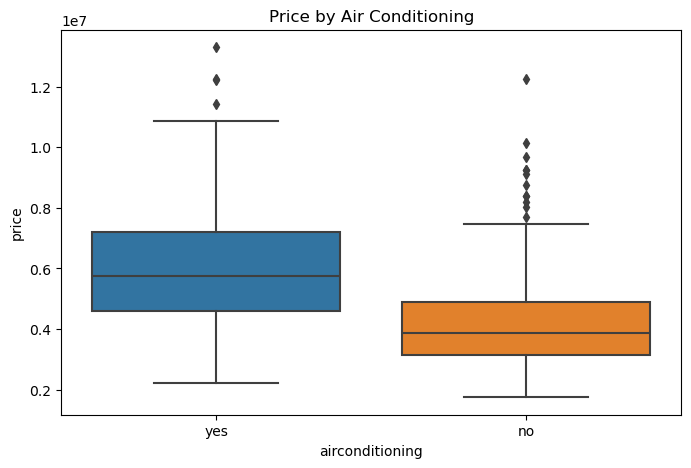

In [409]:
# 3. Box Plot

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='airconditioning',
    y='price'
)

plt.title('Price by Air Conditioning')

# Saving the pLot locally to be able to use in the report
plt.savefig("boxplot.png", bbox_inches="tight", pad_inches=0.1)

plt.show()

In [383]:
plt.savefig("boxplot.png", dpi=300) 

<Figure size 640x480 with 0 Axes>

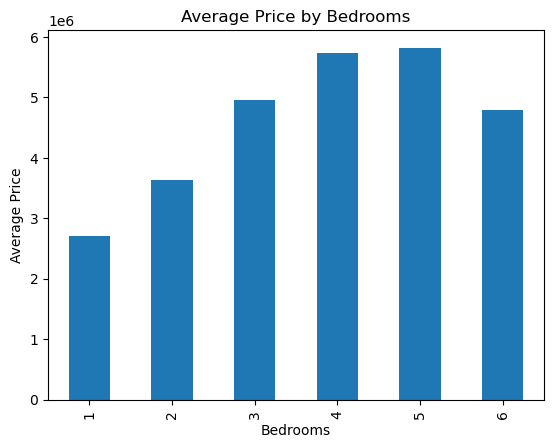

In [389]:
# 4. Bar Chart
avg_price = df.groupby('bedrooms')['price'].mean()

avg_price.plot(kind='bar')

plt.title('Average Price by Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price')

# Saving the pLot locally to be able to use in the report
plt.savefig("plot.png", dpi=300, bbox_inches="tight")

plt.show()

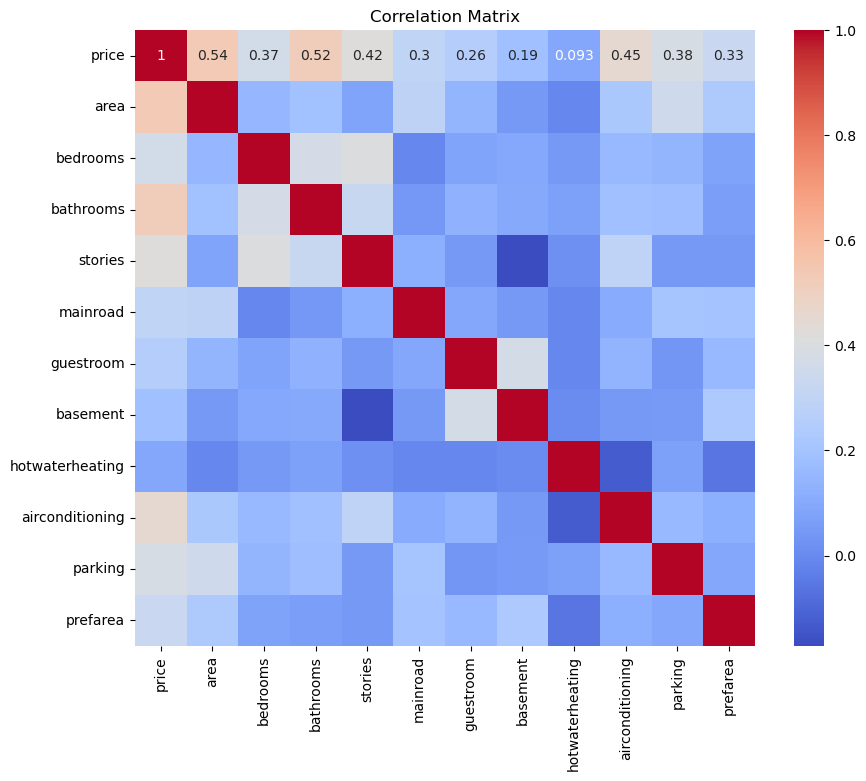

In [413]:
# 5. Heatmap 

# Firstly converting yes/no columns to 1/0

df_corr = df.copy()

binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_corr[col] = df_corr[col].map({'yes':1,'no':0})

plt.figure(figsize=(10,8))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

# Saving the pLot locally to be able to use in the report
plt.savefig("df_corr.png", bbox_inches="tight", pad_inches=0.1)


plt.show()

